<div align="center">

# ASL

</div>

Imports

In [13]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.datasets import SignLanguageMNIST
from src.models import MLP, CNN

<div align="center" style="color: purple">

## **Download dataset**

</div>

In [14]:
# Dane już pobrane — odkomentuj jeśli potrzebujesz pobrać od nowa
# !kaggle datasets download datamunge/sign-language-mnist

## Getting the data

In [15]:
# Dane już wypakowane — odkomentuj jeśli potrzebujesz wypakować od nowa
# import zipfile
# with zipfile.ZipFile("sign-language-mnist.zip", 'r') as zip_ref:
#     zip_ref.extractall("data/asl_mnist")

In [16]:
import pandas as pd

train_path = "data/asl_mnist/sign_mnist_train.csv"
test_path = "data/asl_mnist/sign_mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (27455, 785)
Test shape: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


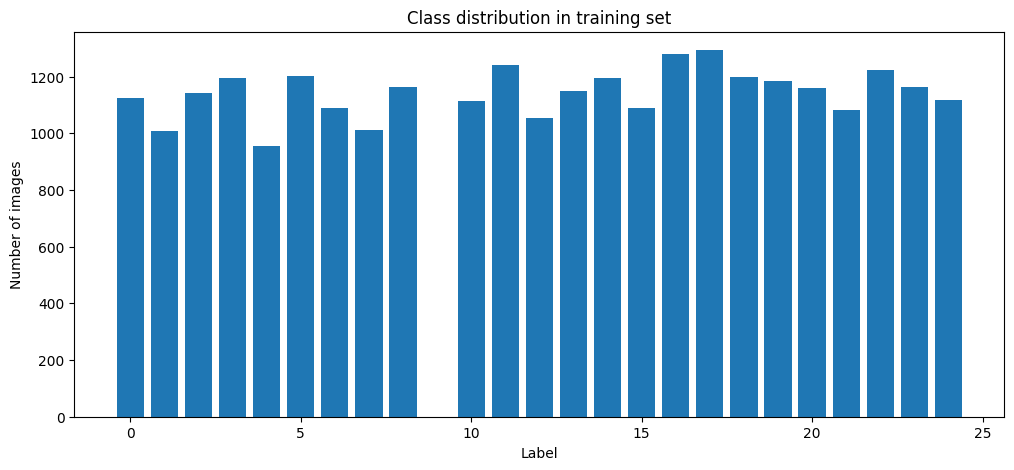

In [17]:
import matplotlib.pyplot as plt

label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Label")
plt.ylabel("Number of images")
plt.title("Class distribution in training set")
plt.show()

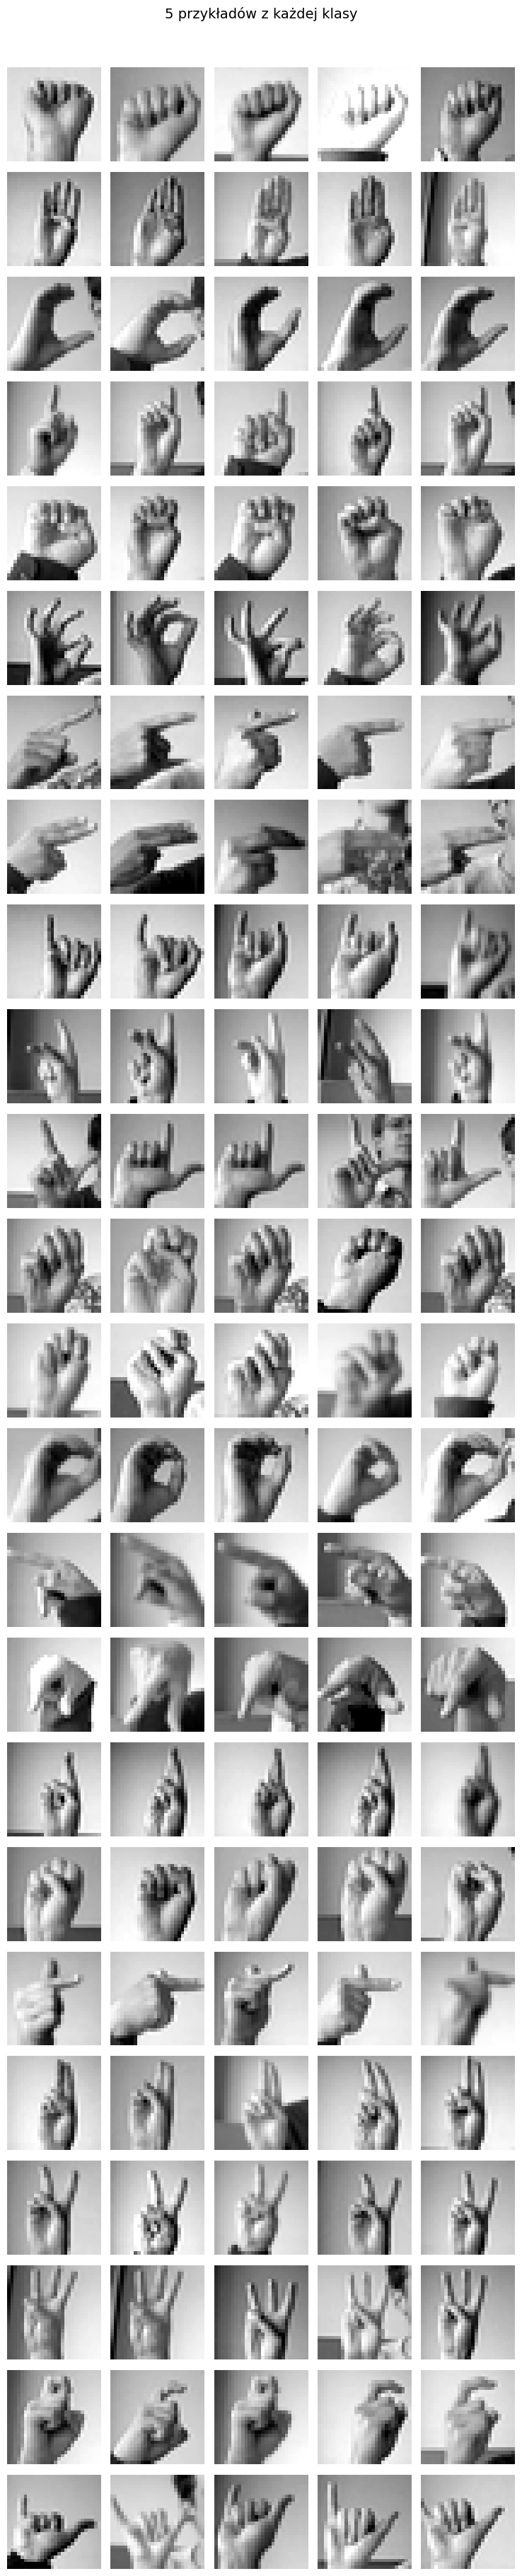

In [18]:
import matplotlib.pyplot as plt
import numpy as np

SAMPLES_PER_CLASS = 5
classes = sorted(train_df["label"].unique())
n_classes = len(classes)

# mapowanie label -> litera (brak J=9 i Z=25)
label_to_letter = {i: chr(ord('A') + i) for i in range(26) if i != 9}

fig, axes = plt.subplots(n_classes, SAMPLES_PER_CLASS, figsize=(SAMPLES_PER_CLASS * 1.5, n_classes * 1.5))

for row, label in enumerate(classes):
    samples = train_df[train_df["label"] == label].iloc[:SAMPLES_PER_CLASS]
    for col in range(SAMPLES_PER_CLASS):
        ax = axes[row, col]
        pixels = samples.iloc[col, 1:].values.reshape(28, 28).astype(np.uint8)
        ax.imshow(pixels, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(label_to_letter.get(label, str(label)), fontsize=10, rotation=0, labelpad=15)

plt.suptitle("5 przykładów z każdej klasy", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Trening

**Criterion** (funkcja straty) — mierzy jak bardzo przewidywania modelu różnią się od prawdziwych etykiet. Model stara się ją minimalizować. Dla klasyfikacji wieloklasowej standardowo używamy `CrossEntropyLoss`, która łączy w sobie `Softmax` + `NLLLoss`.

**Optimizer** — algorytm który aktualizuje wagi modelu na podstawie gradientów obliczonych przez kryterium. Porównanie:
- `SGD` — prosty, przewidywalny, wymaga ręcznego tuningu learning rate
- `Adam` — adaptacyjny learning rate dla każdego parametru, zazwyczaj szybciej zbiega

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Device: {DEVICE}")

train_dataset = SignLanguageMNIST("data/asl_mnist/sign_mnist_train.csv")
test_dataset  = SignLanguageMNIST("data/asl_mnist/sign_mnist_test.csv")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

INPUT_SIZE  = 28 * 28
HIDDEN_SIZE = 256
OUTPUT_SIZE = 24

model = MLP(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

Device: mps
MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=24, bias=True)
)


In [20]:
def train_epoch(model, loader, criterion, optimizer, device, flatten=False):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        if flatten:
            images = images.view(images.size(0), -1)  # MLP: 1x28x28 -> 784
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device, flatten=False):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            if flatten:
                images = images.view(images.size(0), -1)
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

In [21]:
EPOCHS = 4
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE, flatten=True)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, DEVICE, flatten=True)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if epoch % 1 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

Epoch   1/4 | Train loss: 2.1995  acc: 0.3604 | Val loss: 1.6725  acc: 0.4975
Epoch   2/4 | Train loss: 1.2973  acc: 0.6170 | Val loss: 1.2922  acc: 0.6032
Epoch   3/4 | Train loss: 0.9840  acc: 0.7085 | Val loss: 1.1688  acc: 0.6509
Epoch   4/4 | Train loss: 0.8038  acc: 0.7667 | Val loss: 1.0785  acc: 0.6598


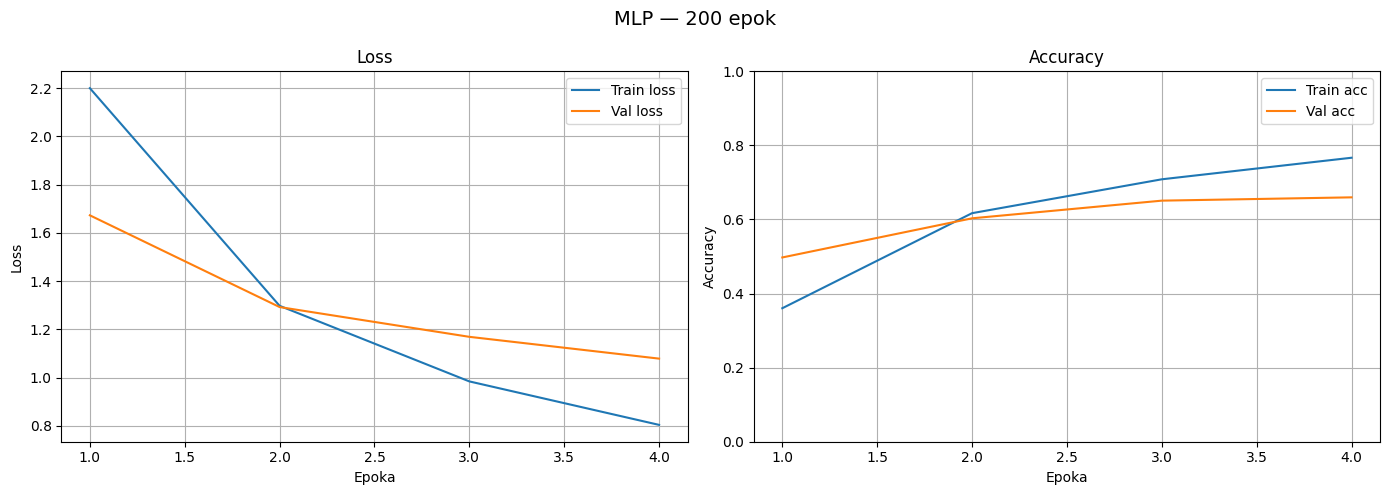


Najlepszy val acc: 0.6598 (epoka 4)


In [22]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
ax1.plot(epochs, history["train_loss"], label="Train loss")
ax1.plot(epochs, history["val_loss"],   label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# --- Accuracy ---
ax2.plot(epochs, history["train_acc"], label="Train acc")
ax2.plot(epochs, history["val_acc"],   label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

plt.suptitle("MLP — 200 epok", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nNajlepszy val acc: {max(history['val_acc']):.4f} (epoka {history['val_acc'].index(max(history['val_acc'])) + 1})")

## Model CNN

Zamiast spłaszczać obraz do wektora (jak MLP), CNN przesuwa małe filtry po obrazie i uczy się wykrywać lokalne wzorce (krawędzie, kształty palców). Każda warstwa widzi coraz bardziej abstrakcyjne cechy.

Architektura:
- **Conv → BatchNorm → ReLU → MaxPool** × 3 bloki (rosnąca liczba filtrów: 32→64→128)
- **Dropout** przed klasyfikatorem — regularyzacja, zmniejsza overfitting
- **FC → FC** — klasyfikator na końcu

In [23]:
model_cnn     = CNN(num_classes=24).to(DEVICE)
criterion_cnn = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

train_loader_cnn = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader_cnn  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

print(model_cnn)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"\nLiczba parametrów CNN: {total_params:,}")

EPOCHS_CNN = 4
history_cnn = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS_CNN + 1):
    train_loss, train_acc = train_epoch(model_cnn, train_loader_cnn, criterion_cnn, optimizer_cnn, DEVICE)
    val_loss,   val_acc   = evaluate(model_cnn, test_loader_cnn, criterion_cnn, DEVICE)

    history_cnn["train_loss"].append(train_loss)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["val_acc"].append(val_acc)

    if epoch % 1 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS_CNN} | "
              f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1152, out_features=256, bias=True

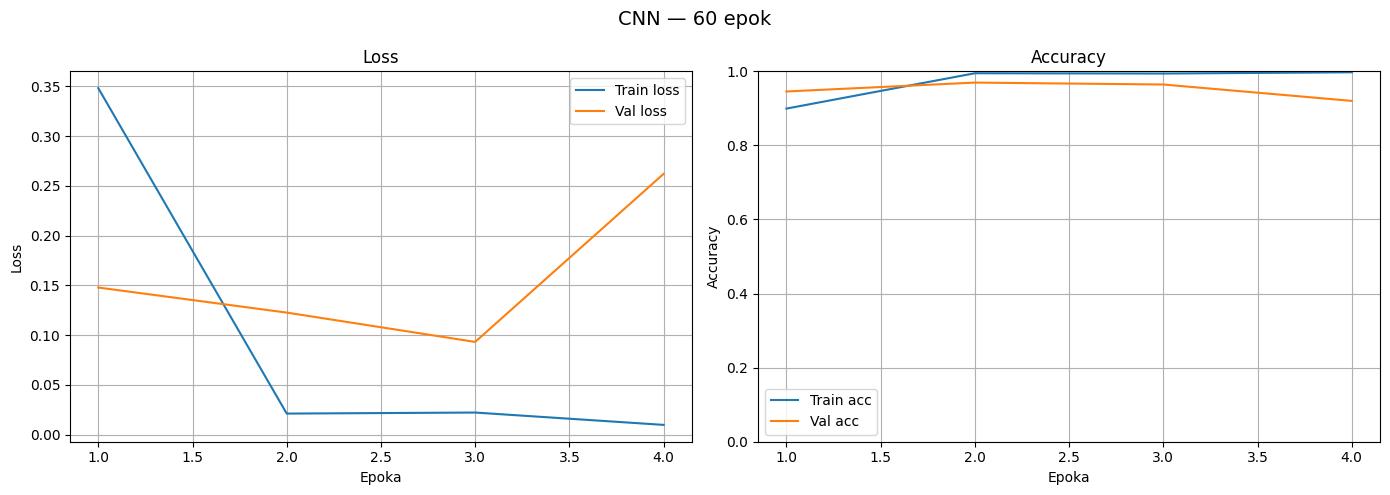

Najlepszy val acc: 0.9696 (epoka 2)


In [24]:
epochs = range(1, EPOCHS_CNN + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history_cnn["train_loss"], label="Train loss")
ax1.plot(epochs, history_cnn["val_loss"],   label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history_cnn["train_acc"], label="Train acc")
ax2.plot(epochs, history_cnn["val_acc"],   label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

plt.suptitle("CNN — 60 epok", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Najlepszy val acc: {max(history_cnn['val_acc']):.4f} (epoka {history_cnn['val_acc'].index(max(history_cnn['val_acc'])) + 1})")